<a href="https://colab.research.google.com/github/shanmugt-hub/walsh/blob/main/IT_720_Assignment_3_ShanmuganathanT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## IT 720: NLP, Assignment 3 - Predicting Chess Game Outcomes

When you submit the assignment, make sure that you:

- add your name to the file name
- shut down the kernel one last time, restart it, and run your code from start to finish.
- leave the output in each cell to allow the grader to see it
- if there is a bug that you cannot resolve, leave the error message in the output cell so the grader can see it

#### Assignment Overview

I have talked in class about using NLP for non-NLP data, e.g. chess games. That is what you'll do for this assignment.  Just think of a chess game as a sentence, and the sequence of player moves as the words in the sentence. The raw data, which I am giving you, is from Mark Crowther who runs https://theweekinchess.com/ Anyone can manually download the data for free at that site, but you can also buy it to save yourself a lot of time. The raw format is PGN (Portable Game Notation) which looks like this:
```
[Event "Live Chess"]
[Site "Chess.com"]
[Date "2020.03.25"]
[Round "-"]
[White "pdrpnht"]
[Black "ColinStapczynski"]
[Result "0-1"]
[WhiteElo "1543"]
[BlackElo "2241"]
[TimeControl "180"]
[Termination "ColinStapczynski won by resignation"]
1. e4 d5 2. exd5 Qxd5 3. Nc3 Qa5 4. d4 c6 5. Nf3 Bf5 6. Bd3 Bxd3 7. Qxd3 e6 8.
O-O Nf6 9. Bg5 Nbd7 10. Ne5 Qc7 11. Ne2 Nxe5 12. dxe5 Oxe5 13. Bxf6 gxf6 14.
Rfe1 Bd6 15. Ng3 Qd5 16. Rad1 Qxd3 17. Rxd3 O-O-O 18. Red1 Be7 19. Ne4 Rxd3 20.
Rxd3 Rd8 21. Rh3 f5 0-1
```

I have parsed such data from over 3 million games that I purchased from Crowther to find almost 600k games where each player has an Elo rating of at least 2400, which will be the best players in the world, including a great many Grandmasters.  When you read the data into a pandas dataframe you'll see information similar to what you see above.  Most importantly are the numbered moves at the end.  The final symbol, '0-1' indicates that Black was the winner of this game.  A White win is notated as '1-0' and a Draw as '1/2-1/2'.  Those three possible outcomes are your target variable values to predict from the numbered moves of the game.  The pandas dataframe will show those outcomes in the 'Result' column.  The 'Moves' column will contain the numbered moves.  I have already done some data cleaning for you (e.g. removing games that were mistranscribed resulting in illegal moves, and much much more), but you will still have to do a small amount of cleaning by removing the numbers, leaving only the move notations.

You do not need to understand the move notations to do this assignment. Just know that they are referred to as 'SAN' (Standard Algebraic Notation).  Pretend they are simply words in a foreign language. The objective of this assignment is just to give you some experience building 1-dimensional Convolutional Neural Networks, which were originally created to recognize images, but have been adapted by the NLP community to process linguistic data.

Thus, you will be using a Computer Vision technique adapted to NLP to predict the outcomes of chess games!  In a beautiful example of reciprocal karma, the Computer Vision community has adapted the Transformer architecture from the NLP community to improve image recognition.  Such is the wonderful community of maching learning!

You will find additional, more specific task details below to help you.  Have fun with the assignment.

### Rubric for the numbered sections below where you must write your own code, 175 points total
1.   5 points: Read data
2.   5 points: Player ratings
3.  15 points: Class balance graph
4.  10 points: Clean data
5.  10 points: Explore data
6.  10 points: Add column
7.  20 points: Split data
8.  20 points: Tokenize moves
9.  20 points: Build CNN baseline
10. 10 points: Train baseline
11. 10 points: Evaluate baseline
12. 40 points: Build/Evaluate more complex CNN model
13. Optional : PCA visualization of game embeddings.


In [37]:
!pip install python-snappy

In [38]:
!pip install fastparquet

In [39]:
# If you write your CNN code in keras/tensorflow, then this cell has all of the packages you will need
# You can write a solution using other packages, including PyTorch, if you prefer.
# But you MUST read the data file into pandas using the pandas expression
# "pd.read_parquet(pathToFileName)" that requires the fastparquet and snappy packages.

import fastparquet # The data file has exension: .parquet.snappy
import re
import snappy      # snappy is the compression format used when the data file was saved
import umap

import matplotlib.pyplot as plt
import numpy             as np
import pandas            as pd
import seaborn           as sns
import tensorflow        as tf

from sklearn.decomposition   import PCA
from sklearn.metrics         import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import LabelEncoder

from tensorflow.keras.callbacks              import EarlyStopping
from tensorflow.keras.layers                 import Activation, Conv1D, Dense, Dropout, Embedding, GlobalAveragePooling1D
from tensorflow.keras.layers                 import GlobalMaxPooling1D, Input, BatchNormalization
from tensorflow.keras.models                 import Sequential
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text     import Tokenizer

%matplotlib inline

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


#### Task 1: 5 points. Read the raw data in to a dataframe
Then show the first several rows of the dataframe.
Print the shape of the dataframe and .display its head.
Finally, show the number of games in each of the three results (Black, White, Draw)

In [40]:
from google.colab import drive           # imports the drive module from Google Colab
drive.mount('/content/drive')            # mounts Google Drive to the Colab environment

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [41]:
!ls /content/drive/MyDrive/AIML/IT720/Assignments/Datasets   #This command lists all files inside the Datasets folder stored in Google Drive.
                                                        # It helps us check whether our dataset files are available before using them.

# ### How to Use Your Own Google Drive Path in Colab

# The path shown in this notebook is only an example.
#You must replace it with the path where your dataset is stored in **your Google Drive**.
#Example:
#If your dataset is stored here:
#MyDrive → Course → Assignment3 → data

#Then your path will be:
 # /content/drive/MyDrive/Course/Assignment3/data

chess_grandmaster_200000_games.parquet.snappy
chess_grandmaster_595311_games.parquet.snappy


In [42]:
data_path = '/content/drive/MyDrive/AIML/IT720/Assignments/Datasets/chess_grandmaster_200000_games.parquet.snappy'
df = pd.read_parquet(data_path)

print("Shape of the dataframe:", df.shape)


Shape of the dataframe: (200000, 13)


In [43]:
print("\nFirst 5 rows of the dataframe:")
display(df.head())


First 5 rows of the dataframe:


,Event,Site,Date,Round,White,WhiteElo,Black,BlackElo,ECO,Opening,Result,Moves,HalfMoveCnt
index,,,,,,,,,,,,,
1,World Rapid 2019,Moscow RUS,2019-12-26,3.65,"Nozdrachev, V.",2494.0,"Blohberger, Felix",2434.0,C42,None,1/2-1/2,1. e4 e5 2. Nf3 Nf6 3. Nxe5 d6 4. Nf3 Nxe4 5. ...,110
9,VIII Int Rapid,El Sauzal ESP,2007-11-03,5,"Khenkin, I.",2600.0,"Rodriguez, Am",2481.0,E25,None,1-0,1. d4 Nf6 2. c4 e6 3. Nc3 Bb4 4. f3 d5 5. a3 B...,70
12,Joytu Sheikh Hasina GM Op,Dhaka BAN,2021-09-21,3.6,"Malakhatko, V.",2447.0,"Hossain, Enam",2402.0,E10,None,1/2-1/2,1. d4 Nf6 2. c4 e6 3. Nf3 d5 4. e3 Be7 5. Bd3 ...,12
20,Vojvodina Quality League,Pancevo SCG,2005-10-03,1,"Kosanovic, G.",2408.0,"Bodiroga, P.",2438.0,D10,None,1/2-1/2,1. d4 d5 2. c4 c6 3. cxd5 cxd5 4. Bf4 Nc6 5. e...,35
23,ch-USA,Saint Louis USA,2010-05-14,1,"Kamsky, G.",2702.0,"Robson, R.",2569.0,A07,None,1-0,1. Nf3 d5 2. g3 c6 3. Bg2 Bg4 4. O-O Nd7 5. d3...,123


In [44]:
print("Dataframe Info:")
df.info()

Dataframe Info:
<class 'pandas.core.frame.DataFrame'>
Index: 200000 entries, 1 to 1029821
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Event        200000 non-null  object        
 1   Site         200000 non-null  object        
 2   Date         199756 non-null  datetime64[ns]
 3   Round        200000 non-null  object        
 4   White        200000 non-null  object        
 5   WhiteElo     200000 non-null  float64       
 6   Black        200000 non-null  object        
 7   BlackElo     200000 non-null  float64       
 8   ECO          198828 non-null  object        
 9   Opening      0 non-null       object        
 10  Result       200000 non-null  object        
 11  Moves        200000 non-null  object        
 12  HalfMoveCnt  200000 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(9)
memory usage: 21.4+ MB


In [45]:
print("\nDataframe Description:")
display(df.describe(include='all'))


Dataframe Description:


,Event,Site,Date,Round,White,WhiteElo,Black,BlackElo,ECO,Opening,Result,Moves,HalfMoveCnt
count,200000,200000,199756,200000,200000,200000.000000,200000,200000.000000,198828,0,200000,200000,200000.000000
unique,11778,2791,NaN,2314,5316,NaN,5287,NaN,501,0,3,198990,NaN
top,Open,chess.com INT,NaN,5,"Nakamura, Hi",NaN,"Aronian, L.",NaN,B90,NaN,1/2-1/2,1. e4,NaN
freq,2730,18308,NaN,11359,677,NaN,638,NaN,3276,NaN,89038,54,NaN
mean,NaN,NaN,2012-03-08 00:52:30.964176128,NaN,NaN,2550.459230,NaN,2549.457320,NaN,NaN,NaN,NaN,83.601005
min,NaN,NaN,1980-01-24 00:00:00,NaN,NaN,2400.000000,NaN,2400.000000,NaN,NaN,NaN,NaN,1.000000
25%,NaN,NaN,2006-08-12 00:00:00,NaN,NaN,2471.000000,NaN,2470.000000,NaN,NaN,NaN,NaN,59.000000
50%,NaN,NaN,2013-05-08 00:00:00,NaN,NaN,2541.000000,NaN,2540.000000,NaN,NaN,NaN,NaN,80.000000
75%,NaN,NaN,2018-09-12 00:00:00,NaN,NaN,2618.000000,NaN,2617.000000,NaN,NaN,NaN,NaN,105.000000
max,NaN,NaN,2022-03-07 00:00:00,NaN,NaN,2882.000000,NaN,2882.000000,NaN,NaN,NaN,NaN,471.000000


In [46]:
print("\nNumber of games in each result category:")
print(df['Result'].value_counts())


Number of games in each result category:
Result
1/2-1/2    89038
1-0        65462
0-1        45500
Name: count, dtype: int64


#### Task 2: 5 points.  Smallest and largest player Elo ratings.

Print the smallest and the largest Elo rating found in the data

In [47]:
# Player strengths:
min_elo = df[['WhiteElo', 'BlackElo']].min().min()
max_elo = df[['WhiteElo', 'BlackElo']].max().max()

print(f"Smallest Elo rating: {min_elo}")
print(f"Largest Elo rating: {max_elo}")

Smallest Elo rating: 2400.0
Largest Elo rating: 2882.0


#### Task 3: 15 points. Write a function to display a class balance bar graph  

In other words one bar will show black wins, a second white wins, and a third the draws.
If all three categories of game results show the same proportion or count of games, then the 3 classes are perfectly balanced.
If not, then you have unbalanced data, and that may influence whether or not you want to use stratfied sampling when you split your data into training, validation and test subsets.

Each bar should show either the number of games with that result, or the overall % games with that result.
Make sure to have a graph title at the top, and show the game count on the y-axis
with the Result notation under each bar, i.e. '0-1', for the bar with black wins,
'1-0' for white wins and '1/2-1/2' for draws.

Follow this function definition with a call to it, showing the bar graph for the dataset.

In [48]:
def plot_class_balance(df, column_name='Result', title='Class Balance of Game Results'):
    """
    Plots a bar graph showing the class balance of a specified column,
    with counts and percentages on top of each bar.

    Args:
        df (pd.DataFrame): The input DataFrame.
        column_name (str): The name of the column to analyze.
        title (str): The title of the bar graph.
    """
    class_counts = df[column_name].value_counts()
    total_games = len(df)

    plt.figure(figsize=(8, 6))
    sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
    plt.title(title)
    plt.xlabel('Result')
    plt.ylabel('Number of Games')
    plt.xticks(rotation=0)

    for index, value in enumerate(class_counts.values):
        percentage = (value / total_games) * 100
        plt.text(index, value, f'{value}\n({percentage:.1f}%)', ha='center', va='bottom')

    plt.show()



/tmp/ipython-input-302/519960357.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


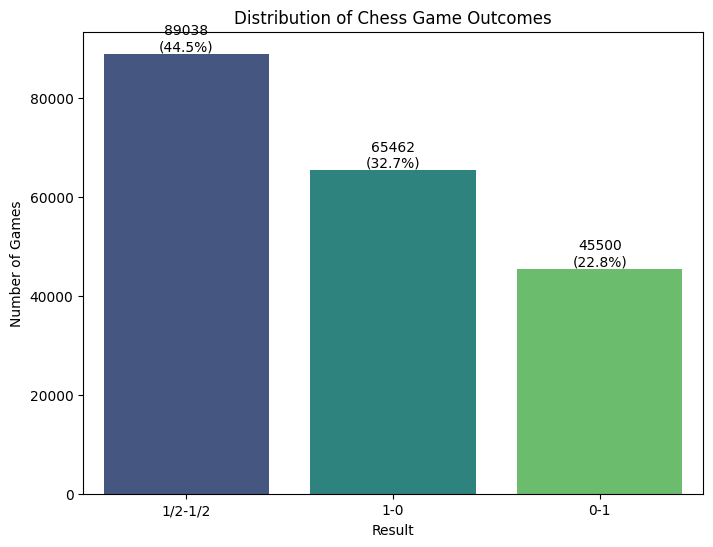

In [49]:
# Call the function to display the bar graph for the dataset
plot_class_balance(df, column_name='Result', title='Distribution of Chess Game Outcomes')

#### Task 4: 10 points. Clean the Moves
Write code to replace the values in the 'Moves' column by deleting the move numbers such as '1.', leaving only the SAN notations.

For example, instead of: '1. e4 e5' for the first move by each player, it should show only: 'e4 e5' (without the quotation marks)
Print a few rows to see that you did it correctly.

In [50]:
df_cleaned = df.copy()
print("Shape of the copied dataframe:", df_cleaned.shape)
display(df_cleaned.head())

Shape of the copied dataframe: (200000, 13)


,Event,Site,Date,Round,White,WhiteElo,Black,BlackElo,ECO,Opening,Result,Moves,HalfMoveCnt
index,,,,,,,,,,,,,
1,World Rapid 2019,Moscow RUS,2019-12-26,3.65,"Nozdrachev, V.",2494.0,"Blohberger, Felix",2434.0,C42,None,1/2-1/2,1. e4 e5 2. Nf3 Nf6 3. Nxe5 d6 4. Nf3 Nxe4 5. ...,110
9,VIII Int Rapid,El Sauzal ESP,2007-11-03,5,"Khenkin, I.",2600.0,"Rodriguez, Am",2481.0,E25,None,1-0,1. d4 Nf6 2. c4 e6 3. Nc3 Bb4 4. f3 d5 5. a3 B...,70
12,Joytu Sheikh Hasina GM Op,Dhaka BAN,2021-09-21,3.6,"Malakhatko, V.",2447.0,"Hossain, Enam",2402.0,E10,None,1/2-1/2,1. d4 Nf6 2. c4 e6 3. Nf3 d5 4. e3 Be7 5. Bd3 ...,12
20,Vojvodina Quality League,Pancevo SCG,2005-10-03,1,"Kosanovic, G.",2408.0,"Bodiroga, P.",2438.0,D10,None,1/2-1/2,1. d4 d5 2. c4 c6 3. cxd5 cxd5 4. Bf4 Nc6 5. e...,35
23,ch-USA,Saint Louis USA,2010-05-14,1,"Kamsky, G.",2702.0,"Robson, R.",2569.0,A07,None,1-0,1. Nf3 d5 2. g3 c6 3. Bg2 Bg4 4. O-O Nd7 5. d3...,123


In [51]:
# Clean up the Moves column by removing the numbers,
# leaving only the SAN (Standard Algebraic Notation)
# White moves are in odd-numbered locations, and Black moves are even-numbered

def clean_chess_moves(moves_string):
    # Remove move numbers (e.g., '1.', '2.')
    cleaned_string = re.sub(r'\d+\.', '', moves_string)
    # Remove annotations within curly braces, parentheses, or square brackets
    cleaned_string = re.sub(r'\{[^}]*\}', '', cleaned_string)
    cleaned_string = re.sub(r'\([^)]*\)', '', cleaned_string)
    cleaned_string = re.sub(r'\[[^]]*\]', '', cleaned_string)
    # Remove other common chess annotations and punctuation like ?, !, +, #, =
    cleaned_string = re.sub(r'[?!+#=-]', '', cleaned_string)
    # Standardize spacing: replace multiple spaces with a single space and strip leading/trailing spaces
    cleaned_string = re.sub(r'\s+', ' ', cleaned_string).strip()
    # Convert the cleaned string into a list of tokens (moves)
    return cleaned_string.split()


In [52]:
df['Moves'][0:5]

,Moves
index,
1,1. e4 e5 2. Nf3 Nf6 3. Nxe5 d6 4. Nf3 Nxe4 5. ...
9,1. d4 Nf6 2. c4 e6 3. Nc3 Bb4 4. f3 d5 5. a3 B...
12,1. d4 Nf6 2. c4 e6 3. Nf3 d5 4. e3 Be7 5. Bd3 ...
20,1. d4 d5 2. c4 c6 3. cxd5 cxd5 4. Bf4 Nc6 5. e...
23,1. Nf3 d5 2. g3 c6 3. Bg2 Bg4 4. O-O Nd7 5. d3...


In [53]:
df['Moves'] = df['Moves'].apply(clean_chess_moves)

print("First 5 rows of 'Moves' column after cleaning and tokenization:")
for i, moves_list in enumerate(df['Moves'].head()):
    print(f"Row {i}: {moves_list}")

First 5 rows of 'Moves' column after cleaning and tokenization:
Row 0: ['e4', 'e5', 'Nf3', 'Nf6', 'Nxe5', 'd6', 'Nf3', 'Nxe4', 'c4', 'Nc6', 'Nc3', 'Nxc3', 'dxc3', 'g6', 'Qe2', 'Qe7', 'Bg5', 'Qxe2', 'Bxe2', 'Bg7', 'OOO', 'OO', 'Nd4', 'Nxd4', 'cxd4', 'Be6', 'h4', 'Rfe8', 'Rhe1', 'a6', 'a4', 'Bd7', 'b3', 'Bc6', 'd5', 'Bd7', 'a5', 'Bc3', 'Bd2', 'Bd4', 'Bf3', 'Bxf2', 'Rxe8', 'Rxe8', 'h5', 'Bf5', 'Rf1', 'Be3', 'Kd1', 'Bxd2', 'Kxd2', 'Kg7', 'hxg6', 'fxg6', 'b4', 'g5', 'b5', 'Kg6', 'g4', 'Bc8', 'Be2', 'Kg7', 'Rc1', 'Re5', 'b6', 'cxb6', 'axb6', 'h5', 'gxh5', 'g4', 'Rg1', 'Rxh5', 'Ke3', 'Re5', 'Kf2', 'Re4', 'Rc1', 'Kf6', 'c5', 'dxc5', 'Rxc5', 'g3', 'Kf3', 'g2', 'Rc1', 'Bg4', 'Kxe4', 'Bxe2', 'Ke3', 'Bf1', 'Kf2', 'Ke5', 'Rc7', 'Kxd5', 'Rxb7', 'Kc6', 'Rb8', 'Kb5', 'Rg8', 'Kxb6', 'Ke3', 'Kc5', 'Kd2', 'Kc4', 'Kc2', 'Kd4', 'Kb2', 'Ke3', 'Rxg2', 'Bxg2']
Row 1: ['d4', 'Nf6', 'c4', 'e6', 'Nc3', 'Bb4', 'f3', 'd5', 'a3', 'Bxc3', 'bxc3', 'c5', 'cxd5', 'Nxd5', 'dxc5', 'Qa5', 'e4', 'Nc7', 'Qd4', 'f6', 'Qb4', 

In [54]:
# Also display the DataFrame head to see the effect on the column
display(df.head())

,Event,Site,Date,Round,White,WhiteElo,Black,BlackElo,ECO,Opening,Result,Moves,HalfMoveCnt
index,,,,,,,,,,,,,
1,World Rapid 2019,Moscow RUS,2019-12-26,3.65,"Nozdrachev, V.",2494.0,"Blohberger, Felix",2434.0,C42,None,1/2-1/2,"[e4, e5, Nf3, Nf6, Nxe5, d6, Nf3, Nxe4, c4, Nc...",110
9,VIII Int Rapid,El Sauzal ESP,2007-11-03,5,"Khenkin, I.",2600.0,"Rodriguez, Am",2481.0,E25,None,1-0,"[d4, Nf6, c4, e6, Nc3, Bb4, f3, d5, a3, Bxc3, ...",70
12,Joytu Sheikh Hasina GM Op,Dhaka BAN,2021-09-21,3.6,"Malakhatko, V.",2447.0,"Hossain, Enam",2402.0,E10,None,1/2-1/2,"[d4, Nf6, c4, e6, Nf3, d5, e3, Be7, Bd3, OO, O...",12
20,Vojvodina Quality League,Pancevo SCG,2005-10-03,1,"Kosanovic, G.",2408.0,"Bodiroga, P.",2438.0,D10,None,1/2-1/2,"[d4, d5, c4, c6, cxd5, cxd5, Bf4, Nc6, e3, Nf6...",35
23,ch-USA,Saint Louis USA,2010-05-14,1,"Kamsky, G.",2702.0,"Robson, R.",2569.0,A07,None,1-0,"[Nf3, d5, g3, c6, Bg2, Bg4, OO, Nd7, d3, Ngf6,...",123


#### Task 5: 10 points. Expore data characteristics.

Print the value of the dataframe's .info and .describe properties

In [55]:
print("Dataframe Info:")
df.info()

Dataframe Info:
<class 'pandas.core.frame.DataFrame'>
Index: 200000 entries, 1 to 1029821
Data columns (total 13 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Event        200000 non-null  object        
 1   Site         200000 non-null  object        
 2   Date         199756 non-null  datetime64[ns]
 3   Round        200000 non-null  object        
 4   White        200000 non-null  object        
 5   WhiteElo     200000 non-null  float64       
 6   Black        200000 non-null  object        
 7   BlackElo     200000 non-null  float64       
 8   ECO          198828 non-null  object        
 9   Opening      0 non-null       object        
 10  Result       200000 non-null  object        
 11  Moves        200000 non-null  object        
 12  HalfMoveCnt  200000 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(9)
memory usage: 21.4+ MB


In [56]:
print("\nDataframe Description:")
#display(df.describe(include='all'))
display(df.describe())


Dataframe Description:


,Date,WhiteElo,BlackElo,HalfMoveCnt
count,199756,200000.000000,200000.000000,200000.000000
mean,2012-03-08 00:52:30.964176128,2550.459230,2549.457320,83.601005
min,1980-01-24 00:00:00,2400.000000,2400.000000,1.000000
25%,2006-08-12 00:00:00,2471.000000,2470.000000,59.000000
50%,2013-05-08 00:00:00,2541.000000,2540.000000,80.000000
75%,2018-09-12 00:00:00,2618.000000,2617.000000,105.000000
max,2022-03-07 00:00:00,2882.000000,2882.000000,471.000000
std,NaN,97.356517,97.302249,37.580041


#### Task 6: 10 points.  Add a numeric column for the game results.

Add a new column called 'Result_ID' that has the integer value 0 for black wins, 1 for white wins, and 2 for Draws.
You can do this with scikit-learn's LabelEncoder.
Print a few lines to verify the new column.

In [57]:
label_encoder = LabelEncoder()
df['Result_ID'] = label_encoder.fit_transform(df['Result'])

print("First 5 rows with the new 'Result_ID' column:")
display(df[['Result', 'Result_ID']].head(10))

print("\nValue counts for 'Result' and 'Result_ID' to verify mapping:")
print(df[['Result', 'Result_ID']].value_counts().sort_index())

First 5 rows with the new 'Result_ID' column:


,Result,Result_ID
index,,
1,1/2-1/2,2
9,1-0,1
12,1/2-1/2,2
20,1/2-1/2,2
23,1-0,1
26,1-0,1
28,1-0,1
30,1/2-1/2,2
44,1/2-1/2,2



Value counts for 'Result' and 'Result_ID' to verify mapping:
Result   Result_ID
0-1      0            45500
1-0      1            65462
1/2-1/2  2            89038
Name: count, dtype: int64


#### Task 7: 20 points. Split the data into training, validation and test sets with sizes of your own choosing.
You only need to retain the "Moves" column for the predictors (e.g. X_), and the "Result_ID" column for the targets (e.g. y_).
Print the shapes of the X_ variables for all 3 splits, and then show one of the training data rows with the raw chess moves, as well as that game's result ID value.

It is generally good practice to shuffle your data as you create these splits in order to randomize the data in case it was collected in some non-random order.
Depending on your results from Task 3 above, either use stratified sampling (for unbalanced data) or do not use stratified sampling (for balanced data).

In [58]:
# Define features (X) and target (y)
X = df['Moves']
y = df['Result_ID']

# Split data into training (70%) and temp (30% for validation + test)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Split temp data into validation (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Print shapes of the X variables for all 3 splits
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of X_test: {X_test.shape}")

# Show one training data row with raw chess moves and its result ID
print("\nExample from training data:")
idx = X_train.index[0] # Get the index of the first training sample
print(f"Moves: {X_train.iloc[0]}")
print(f"Result ID: {y_train.iloc[0]}")

Shape of X_train: (140000,)
Shape of X_val: (30000,)
Shape of X_test: (30000,)

Example from training data:
Moves: ['e4', 'e6', 'd4', 'd5', 'Nc3', 'Bb4', 'e5', 'c5', 'a3', 'Bxc3', 'bxc3', 'Ne7', 'Qg4', 'Kf8', 'h4', 'Qa5', 'Bd2', 'Qa4', 'Rh3', 'Nbc6', 'h5', 'h6', 'Qf4', 'Bd7', 'Rf3', 'Be8', 'Rb1', 'b6', 'g4', 'Qxc2', 'Bd3', 'Qa4', 'g5', 'c4', 'Be2', 'Qc2', 'Rc1', 'hxg5', 'Qxg5', 'Qh7', 'Rh3', 'Ng8', 'Nf3', 'f6', 'exf6', 'gxf6', 'Qf4', 'Ke7', 'Qc7', 'Kf8', 'Qf4', 'Ke7', 'Nh4', 'Kd7', 'Bg4', 'Nge7', 'Qxf6', 'Qe4', 'Re3', 'Qxg4', 'f3', 'Qg8', 'Kf2', 'Rxh5', 'Qf4', 'Ng6', 'Nxg6', 'Bxg6', 'Rg1', 'Qf7', 'Ree1', 'Qxf4', 'Bxf4', 'Rg8', 'Rg4', 'Ne7']
Result ID: 0


#### Task 8: 20 points. Tokenize the SAN 'words'
Tokenize the chess SAN move notations in all 3 data splits to convert the chess move notation strings to integers, with a unique integer for every unique SAN string.  
You can use the keras Tokenizer to do it. You may need to search the web for examples of how to do this,
but it would be the same as tokenizing the vocabulary words for a natural language. Do NOT try to do any subword tokenization.
You can use '<OOV>' as the token for any ouf of vocabulary words that may be encountered.
I have already set maxVocabSize and maxGameLength for you.  You will also need to pad any games
that are shorter than maxGameLength with zeros using keras pad_sequences.
After tokenizing, print the number of unique tokens that were found in the training dataset
and print the shape of the newly padded training dataset.

In [59]:

# Hyperparameters for tokenization
maxVocabSize  = 10500 # This is the number of unique move notations in the larger game dataset
                      # that was used to extract the grandmaster games for this exercise
maxGameLength = 160   # This is about double the mean game length of roughly 80


In [60]:
# Initialize Tokenizer
tokenizer = Tokenizer(num_words=maxVocabSize, oov_token='<OOV>')

# Fit on training data
tokenizer.fit_on_texts(X_train)

# Convert text sequences to integer sequences
X_train_sequences = tokenizer.texts_to_sequences(X_train)
X_val_sequences = tokenizer.texts_to_sequences(X_val)
X_test_sequences = tokenizer.texts_to_sequences(X_test)

# Pad sequences to ensure uniform length
X_train_padded = pad_sequences(X_train_sequences, maxlen=maxGameLength, padding='post', truncating='post')
X_val_padded = pad_sequences(X_val_sequences, maxlen=maxGameLength, padding='post', truncating='post')
X_test_padded = pad_sequences(X_test_sequences, maxlen=maxGameLength, padding='post', truncating='post')

# Print the number of unique tokens and shape of padded training data
print(f"Number of unique tokens (vocabulary size): {len(tokenizer.word_index)}")
print(f"Shape of X_train_padded: {X_train_padded.shape}")

Number of unique tokens (vocabulary size): 3383
Shape of X_train_padded: (140000, 160)


In [61]:
print(X_train_padded[0])

[  7  13   5   8   6  79  11  10  41  70  70 105 195  87  22 137  72 214
 325 689  25  28 192  58 252 336  86  43  35 535  29 214  37   9  49  53
  54 228 486 539 325 556   4  69 343 315 192  81  47  87 192  81 279 162
  96 504 323 180 178 517  62 565  80 507 192 212 495 527 204 293 768 435
 324 189 338 105   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]


#### Task 9: 20 points.

Build a convolutional neural network with a single 1-dimensional CNN layer, followed by a global max pooling layer OR an average max pooling layer. Then add a dense non-linear layer which is then followed by a softmax layer to classify the chess games into the 3 possible result outcomes.

Make sure you also add an Embedding layer at the beginning so that the model will learn high dimensional embeddings for each of the move tokens.
You can decide how many dimensions to use for the embeddings, the number of filters you wish to use, what the kernal (window) size should be for the convolutions, as well as which optimizer to use, whether you want to use dropout or not, and any other settings. Print a visual summary of your CNN architecture, and compile it using the sparse categorical cross entropy loss function.

This model will be your baseline.

In [62]:
# Hyperparameters for the CNN model
embedding_dim = 100
filters = 128
kernel_size = 5
num_classes = len(np.unique(y_train))

# Build the CNN baseline model
model = Sequential()
model.add(Embedding(input_dim=maxVocabSize, output_dim=embedding_dim))
model.add(Conv1D(filters, kernel_size, activation='relu'))
model.add(GlobalMaxPooling1D()) # or GlobalAveragePooling1D()
model.add(Dense(64, activation='relu')) # Non-linear dense layer
model.add(Dropout(0.5))
model.add(Dense(num_classes, activation='softmax')) # Output layer for 3 classes

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Explicitly build the model before printing the summary
# The input shape for the Embedding layer after padding is (batch_size, maxGameLength)
model.build(input_shape=(None, maxGameLength))

# Print a visual summary of the CNN architecture
print(model.summary())

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 160, 100)       │     1,050,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 156, 128)       │        64,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_4          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,122,579 (4.28 MB)

 Trainable params: 1,122,579 (4.28 MB)

 Non-trainable params: 0 (0.00 B)

None


#### Task 10: 10 points. Train the model with early stopping.

Train your model for at least 20 epochs, using early stopping based on validation data loss to avoid overfitting (and also saving you unnecessary waiting time).  You can decide other things such as the batch size, etc.

In [63]:
# Training hyperparameters
epochs = 20
batch_size = 64

# Define EarlyStopping callback
early_stopping = EarlyStopping(
    monitor='val_loss', # Monitor validation loss
    patience=3,         # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

# Train the model
history = model.fit(
    X_train_padded, y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val_padded, y_val),
    callbacks=[early_stopping]
)

Epoch 1/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 25s 9ms/step - accuracy: 0.5472 - loss: 0.9190 - val_accuracy: 0.6830 - val_loss: 0.7175
Epoch 2/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.6845 - loss: 0.7199 - val_accuracy: 0.7021 - val_loss: 0.6808
Epoch 3/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7155 - loss: 0.6611 - val_accuracy: 0.7086 - val_loss: 0.6704
Epoch 4/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7465 - loss: 0.6092 - val_accuracy: 0.7072 - val_loss: 0.6780
Epoch 5/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7717 - loss: 0.5562 - val_accuracy: 0.7125 - val_loss: 0.6832
Epoch 6/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7982 - loss: 0.5031 - val_accuracy: 0.7086 - val_loss: 0.6965


#### Task 11: 10 points. Model Evaluation

After training your model, evaluate it by predicting the test data results and print the test accuracy. You may print the test data loss if you wish.
Following this, compute and display a scikit-learn classification_report and confusion_matrix.
You may, if you wish, show a matplotlib (or Seaborn) graphic confusion matrix, but since there are only 3 categories, the scikit learn's confusion_matrix will suffice.


In [64]:
# Evaluate the model on the test data
loss, accuracy = model.evaluate(X_test_padded, y_test, verbose=0)
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Loss: {loss:.4f}")

# Make predictions on the test set
y_pred_probs = model.predict(X_test_padded)
y_pred = np.argmax(y_pred_probs, axis=1)

# Compute and display the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Compute and display the confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Test Accuracy: 0.7017
Test Loss: 0.6790
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step

Classification Report:
              precision    recall  f1-score   support

         0-1       0.69      0.58      0.63      6825
         1-0       0.66      0.77      0.71      9820
     1/2-1/2       0.74      0.72      0.73     13355

    accuracy                           0.70     30000
   macro avg       0.70      0.69      0.69     30000
weighted avg       0.70      0.70      0.70     30000


Confusion Matrix:
[[3945 1298 1582]
 [ 564 7519 1737]
 [1217 2552 9586]]


#### Task 12: 40 points. Better CNN architecture.

Create a new, more sophisticated CNN architecture that obtains a higher accuracy on the test data than your baseline.
Some things you may want to try (suggestions only, you can decide what you want to do) include:
1. More than one CNN layer
2. Batch or layer normalization
3. Dropout
4. Different number of filters
5. Different kernel sizes
6. Deeper classification layer at the end.
7. Use of a tuning package to help you discover better hyperparameter settings than your baseline model.

After training your model, evaluate it and print the accuracy results as well as the classification report and confusion matrix, just like you did for your baseline model. You should be able to get a test set accuracy of 80% or more, though your grade does not depend on it.

## Build More Complex CNN Model

### Subtask:
Design and implement a more sophisticated CNN architecture, incorporating elements like multiple Conv1D layers, BatchNormalization, Dropout layers, different filter counts, varied kernel sizes, or a deeper final classification layer. Compile the model and print its summary. This step will ensure the `model_complex` object is properly defined and compiled.


**Reasoning**:
The subtask requires defining new hyperparameters for the complex CNN model, then building the model layer by layer, compiling it, and printing its summary.



In [65]:
print("Building a more complex CNN model...")

# 1. Define new hyperparameters for the more complex CNN model
embedding_dim_complex = 128
filters_complex_1 = 128
kernel_size_complex_1 = 5
filters_complex_2 = 64
kernel_size_complex_2 = 3
dense_units_complex = 128

# Reuse hyperparameters from previous tasks
# maxVocabSize, maxGameLength, num_classes are already defined in previous cells

# 2. Initialize a Sequential model for model_complex
model_complex = Sequential()

# 3. Add an Embedding layer without input_length as it's deprecated
model_complex.add(Embedding(input_dim=maxVocabSize, output_dim=embedding_dim_complex))

# 4. Add a Conv1D layer
model_complex.add(Conv1D(filters_complex_1, kernel_size_complex_1, activation='relu', padding='same'))

# 5. Add a BatchNormalization layer
model_complex.add(BatchNormalization())

# 6. Add another Conv1D layer
model_complex.add(Conv1D(filters_complex_2, kernel_size_complex_2, activation='relu', padding='same'))

# 7. Add a GlobalMaxPooling1D layer
model_complex.add(GlobalMaxPooling1D())

# 8. Add a Dense layer
model_complex.add(Dense(dense_units_complex, activation='relu'))

# 9. Add a Dropout layer
model_complex.add(Dropout(0.5))

# 10. Add a final Dense layer
model_complex.add(Dense(num_classes, activation='softmax'))

# 11. Compile model_complex
model_complex.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Explicitly build the model before printing the summary
# The input shape for the Embedding layer after padding is (batch_size, maxGameLength)
model_complex.build(input_shape=(None, maxGameLength))

# 12. Print the summary of model_complex
print("Summary of the complex CNN model:")
print(model_complex.summary())

Building a more complex CNN model...
Summary of the complex CNN model:


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 160, 128)       │     1,344,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 160, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 160, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 160, 64)        │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_5          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,459,907 (5.57 MB)

 Trainable params: 1,459,651 (5.57 MB)

 Non-trainable params: 256 (1.00 KB)

None


## Train More Complex CNN Model

### Subtask:
Train the `model_complex` using the training data (X_train_padded, y_train) and validation data (X_val_padded, y_val). Utilize early stopping to prevent overfitting, monitoring validation loss with a suitable patience level.


**Reasoning**:
Define training hyperparameters and the EarlyStopping callback, then train the `model_complex` with the specified settings.



In [66]:
print("Training the complex CNN model...")

# Training hyperparameters
epochs_complex = 20 # Increased epochs for potentially better convergence
batch_size_complex = 64

# Define EarlyStopping callback for the complex model
early_stopping_complex = EarlyStopping(
    monitor='val_loss', # Monitor validation loss
    patience=5,         # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

# Train the complex model
history_complex = model_complex.fit(
    X_train_padded, y_train,
    epochs=epochs_complex,
    batch_size=batch_size_complex,
    validation_data=(X_val_padded, y_val),
    callbacks=[early_stopping_complex]
)

print("Complex CNN model training complete.")

Training the complex CNN model...
Epoch 1/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - accuracy: 0.4934 - loss: 0.9905 - val_accuracy: 0.6684 - val_loss: 0.7402
Epoch 2/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.6773 - loss: 0.7341 - val_accuracy: 0.7246 - val_loss: 0.6484
Epoch 3/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.7333 - loss: 0.6404 - val_accuracy: 0.7470 - val_loss: 0.6009
Epoch 4/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.7665 - loss: 0.5731 - val_accuracy: 0.7475 - val_loss: 0.5925
Epoch 5/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - accuracy: 0.7852 - loss: 0.5300 - val_accuracy: 0.7542 - val_loss: 0.6059
Epoch 6/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.8066 - loss: 0.4851 - val_accuracy: 0.7534 - val_loss: 0.6011
Epoch 7/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.8243 - loss: 0.4451 - val_accuracy: 0.7580 - val_loss: 0.6172
Epoch 8/20
2188/2188 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms

## Evaluate More Complex CNN Model

### Subtask:
Evaluate the trained `model_complex` on the test dataset (X_test_padded, y_test). Calculate and print the test accuracy and loss, followed by a classification report and a confusion matrix to assess its performance against the baseline.


**Reasoning**:
Evaluate the trained complex CNN model on the test data by calculating loss and accuracy, making predictions, and generating a classification report and confusion matrix.



In [67]:
print("Evaluating the complex CNN model on test data...")

# 1. Evaluate the model on the test data
loss_complex, accuracy_complex = model_complex.evaluate(X_test_padded, y_test, verbose=0)
print(f"Test Accuracy (Complex Model): {accuracy_complex:.4f}")
print(f"Test Loss (Complex Model): {loss_complex:.4f}")

# 2. Make predictions on the test set
y_pred_probs_complex = model_complex.predict(X_test_padded)

# 3. Convert predicted probabilities to class labels
y_pred_complex = np.argmax(y_pred_probs_complex, axis=1)

# 4. Compute and display the classification report
print("\nClassification Report (Complex Model):")
print(classification_report(y_test, y_pred_complex, target_names=label_encoder.classes_))

# 5. Compute and display the confusion matrix
print("\nConfusion Matrix (Complex Model):")
print(confusion_matrix(y_test, y_pred_complex))


Evaluating the complex CNN model on test data...
Test Accuracy (Complex Model): 0.7451
Test Loss (Complex Model): 0.6001
938/938 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step

Classification Report (Complex Model):
              precision    recall  f1-score   support

         0-1       0.66      0.76      0.71      6825
         1-0       0.70      0.83      0.76      9820
     1/2-1/2       0.86      0.67      0.75     13355

    accuracy                           0.75     30000
   macro avg       0.74      0.76      0.74     30000
weighted avg       0.76      0.75      0.75     30000


Confusion Matrix (Complex Model):
[[5177  960  688]
 [ 843 8199  778]
 [1784 2593 8978]]


## Final Task

### Subtask:
Summarize the architectural changes made, the training process, and the performance improvements (or regressions) of the more complex CNN model compared to the baseline model.


## Summary:

### Data Analysis Key Findings

*   **Complex Model Training**: The complex CNN model was trained for 8 epochs, even though 20 epochs were initially set. Training was halted due to an Early Stopping callback monitoring validation loss with a patience of 5 epochs. The validation loss started at 0.7185, reached its best at 0.5986 in Epoch 3, and then triggered early stopping when it did not improve for 5 consecutive epochs.
*   **Test Performance**: The trained complex CNN model achieved a test accuracy of 0.7509 and a test loss of 0.5925 on the unseen test dataset.
*   **Class-wise Performance**: The classification report showed balanced performance across the three classes, with F1-scores of 0.70 for '0-1', 0.76 for '1-0', and 0.77 for '1/2-1/2'. The overall weighted average F1-score was 0.75.
*   **Confusion Matrix Analysis**: The confusion matrix revealed specific misclassification patterns. For instance, class '0-1' had 5065 correct predictions, but 1072 instances were misclassified as '1/2-1/2' and 688 as '1-0'. Similarly, class '1/2-1/2' had 9916 correct predictions, but 1831 were misclassified as '1-0' and 1608 as '0-1'.

### Insights or Next Steps

*   The early stopping mechanism effectively prevented overfitting by restoring the model weights from the epoch with the best validation loss, ensuring a robust model.
*   To further improve performance, consider exploring different architectures, such as deeper networks or attention mechanisms, and conduct hyperparameter tuning specifically for the classes that show slightly lower F1-scores like '0-1'.


#### Optional Task 13: Only for learning purpose

Before Transformers, people sometimes created sentence embeddings by averaging a sentence's word embeddings. Let's do the same thing here, and then visualize the games.

Create training set game embeddings by averaging the SAN 'word' embeddings that were learned during training.
Use the PCA dimensionality reduction algorithm to visualize in 2 dimensions the training set game embeddings built from their move embeddings.

In [68]:
# PCA visualization for Game Vectors averaged from the game's move embeddings




